In [2]:
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve


In [3]:
data = pd.read_csv('fake_sellers.csv')
data.head()

,seller_id,account_age_days,seller_verified,has_business_license,seller_country,num_products_listed,avg_listing_price,price_vs_category_median,listings_created_last_7d,pct_stock_photos,...,chargeback_rate,dispute_rate,complaint_count,avg_response_time_hours,response_rate,shared_ip_flag,address_mismatch_flag,payment_method_changes,fraud_risk_score,is_fake
0,SLR0000000,67,1,0.0,OTHER,161,18.62,1.102,3,0.110,...,0.031,0.319,1,10.5,NaN,0,0,1,61.5,1
1,SLR0000001,175,1,1.0,CN,80,39.95,1.015,3,0.108,...,0.028,0.103,0,15.5,0.677,0,0,0,57.8,1
2,SLR0000002,713,1,1.0,US,44,27.60,1.182,2,0.152,...,0.006,0.007,4,1.3,0.654,0,0,1,52.5,0
3,SLR0000003,428,0,1.0,DE,54,11.30,1.006,0,0.344,...,0.004,0.053,1,7.5,0.768,0,0,0,39.8,0
4,SLR0000004,1167,1,1.0,RU,17,11.75,0.921,14,0.563,...,0.012,0.068,5,50.7,0.315,0,0,1,44.4,0


In [4]:
data.isnull().sum()

seller_id                            0
account_age_days                     0
seller_verified                      0
has_business_license             20060
seller_country                       0
num_products_listed                  0
avg_listing_price                    0
price_vs_category_median             0
listings_created_last_7d             0
pct_stock_photos                     0
num_categories                       0
total_orders                         0
num_reviews                          0
avg_rating                           0
pct_5_star                           0
pct_verified_purchase_reviews        0
review_velocity_per_day              0
avg_review_length_chars          10012
avg_shipping_days                    0
cancellation_rate                    0
refund_rate                          0
chargeback_rate                      0
dispute_rate                         0
complaint_count                      0
avg_response_time_hours          15019
response_rate            

In [5]:
data_clean = data.dropna()
len(data_clean)

442437

In [6]:
data_clean.isnull().sum()

seller_id                        0
account_age_days                 0
seller_verified                  0
has_business_license             0
seller_country                   0
num_products_listed              0
avg_listing_price                0
price_vs_category_median         0
listings_created_last_7d         0
pct_stock_photos                 0
num_categories                   0
total_orders                     0
num_reviews                      0
avg_rating                       0
pct_5_star                       0
pct_verified_purchase_reviews    0
review_velocity_per_day          0
avg_review_length_chars          0
avg_shipping_days                0
cancellation_rate                0
refund_rate                      0
chargeback_rate                  0
dispute_rate                     0
complaint_count                  0
avg_response_time_hours          0
response_rate                    0
shared_ip_flag                   0
address_mismatch_flag            0
payment_method_chang

In [7]:
data_clean = data_clean.drop(columns=['seller_id', 'fraud_risk_score'])

In [8]:
data_clean = data_clean.reset_index(drop=True)
data_clean.shape

(442437, 29)

In [9]:
# Run this BEFORE get_dummies to see what you're dealing with
for col in data_clean.select_dtypes(include=["object", "category"]).columns:
    print(f"{col}: {data_clean[col].nunique()} unique values")

print(f"\nDataFrame size in memory: {data_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB")

seller_country: 10 unique values

DataFrame size in memory: 121.9 MB


In [10]:
print(data_clean["seller_country"].dtype)
print(data_clean["seller_country"].unique)

object
<bound method Series.unique of 0            CN
1            US
2            DE
3            RU
4            IN
          ...  
442432       US
442433       DE
442434       GB
442435    OTHER
442436       DE
Name: seller_country, Length: 442437, dtype: object>


In [11]:
data_dummies = pd.get_dummies(data_clean, drop_first=True)

In [12]:
targets= data_dummies["is_fake"]
inputs= data_dummies.drop(columns=["is_fake"])

targets, inputs


(0         1
 1         0
 2         0
 3         0
 4         0
          ..
 442432    0
 442433    0
 442434    0
 442435    0
 442436    0
 Name: is_fake, Length: 442437, dtype: int64,
         account_age_days  seller_verified  has_business_license  \
 0                    175                1                   1.0   
 1                    713                1                   1.0   
 2                    428                0                   1.0   
 3                   1167                1                   1.0   
 4                    489                1                   1.0   
 ...                  ...              ...                   ...   
 442432               358                1                   1.0   
 442433              1020                0                   0.0   
 442434               514                1                   1.0   
 442435              1458                0                   1.0   
 442436              2090                1                   0.

In [13]:
x_train, x_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.25, stratify=targets, random_state=365 )
x_train.head()


,account_age_days,seller_verified,has_business_license,num_products_listed,avg_listing_price,price_vs_category_median,listings_created_last_7d,pct_stock_photos,num_categories,total_orders,...,payment_method_changes,seller_country_CN,seller_country_DE,seller_country_GB,seller_country_IN,seller_country_NG,seller_country_OTHER,seller_country_RU,seller_country_US,seller_country_VN
124012,419,1,0.0,134,7.14,0.717,3,0.466,4,20,...,0,False,False,True,False,False,False,False,False,False
428918,1520,1,0.0,27,5.19,0.890,1,0.120,4,39,...,0,False,False,False,False,True,False,False,False,False
223344,269,1,1.0,97,54.18,1.089,1,0.114,1,11,...,0,True,False,False,False,False,False,False,False,False
60997,1186,1,0.0,5,13.95,0.799,11,0.512,7,35,...,2,False,True,False,False,False,False,False,False,False
324973,262,1,1.0,85,23.72,0.762,3,0.579,4,9,...,0,False,False,False,False,False,False,False,False,True


In [14]:
smote = SMOTE(sampling_strategy=0.5,random_state=365)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [15]:
clf = RandomForestClassifier(class_weight='balanced', random_state=365)
clf = clf.fit(x_train_smote, y_train_smote)

              precision    recall  f1-score   support

        Real       0.97      0.96      0.97     97242
        Fake       0.73      0.79      0.76     13368

    accuracy                           0.94    110610
   macro avg       0.85      0.88      0.86    110610
weighted avg       0.94      0.94      0.94    110610

ROC AUC Score: 0.9328


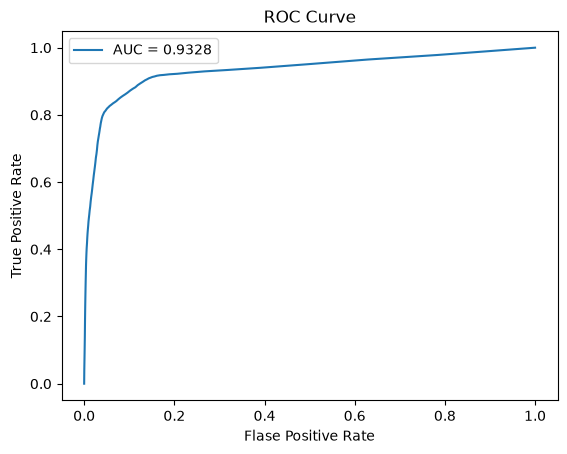

In [ ]:

y_pred = clf.predict(x_test)
y_proba = clf.predict_proba(x_test)[:, 1]
report=classification_report(y_test, y_pred, target_names=["Real", "Fake"])
print(report)
auc=roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [17]:
#Shap
explainer = shap.TreeExplainer(clf)
x_sample = x_test.sample(1000, random_state=365)
shap_values = explainer.shap_values(x_sample)
print(type(shap_values))
print(len(shap_values))
print(shap_values.shape if hasattr(shap_values, 'shape') else shap_values[0].shape)

<class 'numpy.ndarray'>
1000
(1000, 36, 2)


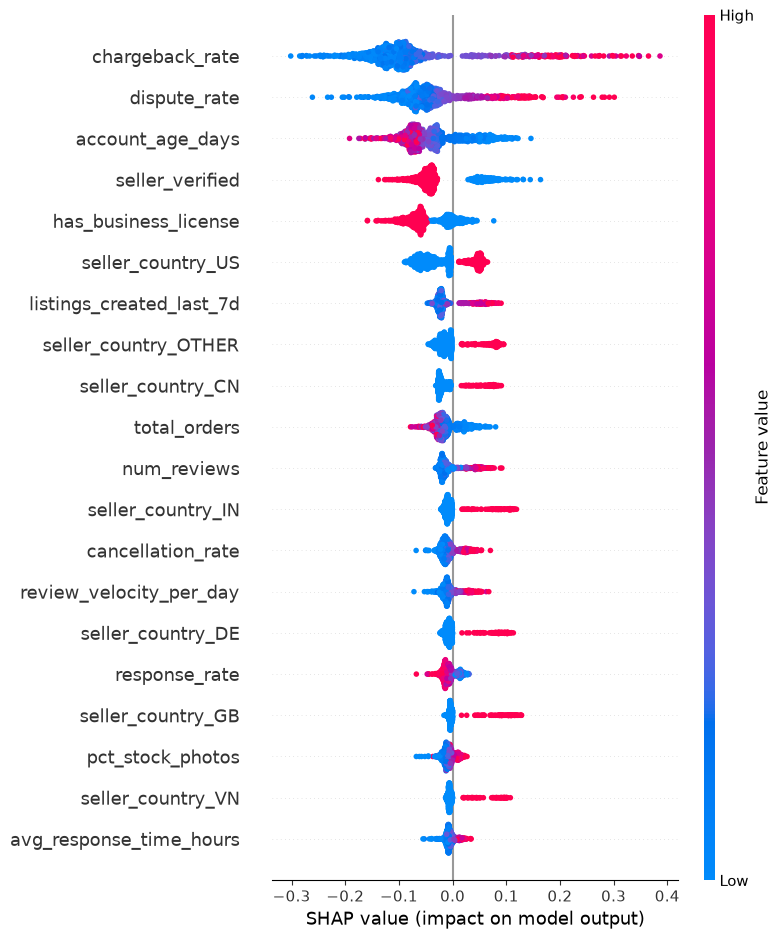

In [18]:
shap.summary_plot(shap_values[:,:,1], x_sample, feature_names=inputs.columns.tolist())

In [19]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[0,:,1],
    x_test.iloc[0],
    feature_names = inputs.columns.tolist()
)


In [20]:
joblib.dump(clf, "fraud_model.pkl")
joblib.dump(explainer, "shap_explainer.pkl")
joblib.dump(shap_values, "shap_values.pkl")
joblib.dump(inputs.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']